# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Andrew Myshkevych Ridley Sisson*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


*Your written answers for Part A:*

- Image size chosen and why: The images are 28 by 28 pixels and so the model is set up to process them at their original resolution.

- Stratification decision and why: It was used during the train and test split to ensure that proportions of 10 types of clothing items in the dataset are maintained in both the training and testing sets. This prevents a skewing of class reprensentation in either set.


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [3]:
# Build your CNN model here
model = Sequential()

#  1st CNN layer
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2), strides=2))

# 2nd CNN layer
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2), strides=2))


model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Compile your model here
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

*Your architecture justification (one paragraph):*

The CNN architecture is made up of two convolutional blocks, each consisting of a Conv2D layer followed by a MaxPooling2D layer. This design allows the network to learn hierarchical features from the input images. The first Conv2D layer uses 32 filters, and the second uses 64 filters, which demonstrates a common practice of increasing the number of filters as the network depth increases. The kernel_size of (3,3) was chosen for both convolutional layers as it is a common and effective size for capturing local features. Each MaxPooling2D layer uses a pool_size of (2,2) with a strides of 2, which makes the model more robust to small variations in the input. Following the convolutional blocks, a Flatten layer converts the 2D feature maps into a 1D vector. This is then fed into a Dense classifier head, starting with a hidden Dense layer of 64 units with relu activation, which is ideal for being non-linear. And lastly, the output layer consists of a Dense layer with 10 units (corresponding to the 10 clothing item types in the fashion dataset) as well as a softmax activation function.

---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [5]:
history = model.fit(x_train.reshape(-1, 28, 28, 1), y_train, epochs=10, validation_data=(x_test.reshape(-1, 28, 28, 1), y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 30ms/step - accuracy: 0.8262 - loss: 0.4779 - val_accuracy: 0.8669 - val_loss: 0.3757
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8856 - loss: 0.3172 - val_accuracy: 0.8824 - val_loss: 0.3178
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9007 - loss: 0.2723 - val_accuracy: 0.8844 - val_loss: 0.3167
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9115 - loss: 0.2407 - val_accuracy: 0.8944 - val_loss: 0.2905
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.9212 - loss: 0.2153 - val_accuracy: 0.9009 - val_loss: 0.2737
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9271 - loss: 0.1947 - val_accuracy: 0.9029 - val_loss: 0.2644
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9339 - loss: 0.1766 - val_accuracy: 0.9040 - val_loss: 0.2643
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9408 -

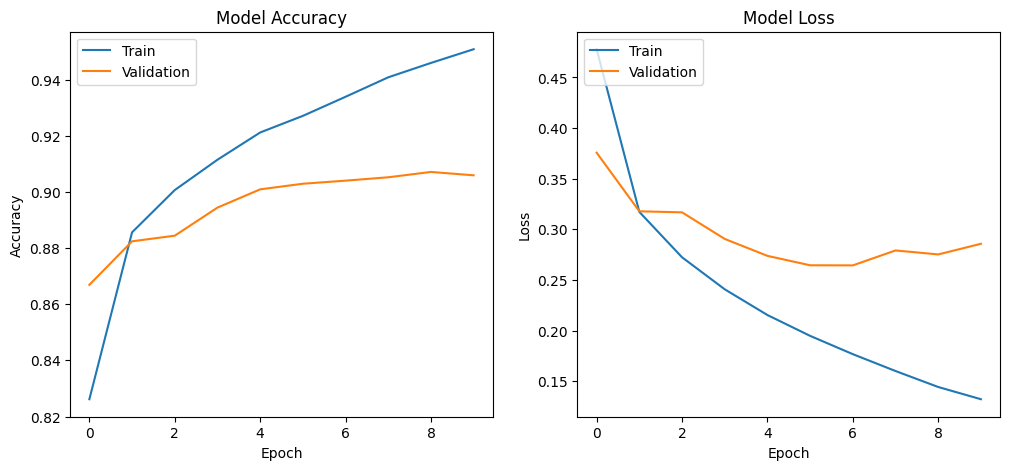

In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

*Your fit diagnosis, with specific evidence from your curve:*

Based on the training and validation curves, the model is overfitting. The training accuracy consistently increases, reaching approximately 95% by the final epoch. However, the validation accuracy, starts to plateau around 91%, and also slightly declines in the last two epochs (91.42% on epoch 8 to 91.18% on epoch 10). This indicates the model is becoming too fitted (overfit) and specialized to the training data.

 The training loss steadily decreases throughout all epochs, ending at a low value of approximately 0.1288. In contrast, the validation loss decreases but then starts to increase after epoch 8. When training loss continues to fall while validation loss rises, it's usually a clear indicator that the model is memorizing the training data rather than learning generalizable patterns.

In [8]:
loss, accuracy = model.evaluate(x_test.reshape(-1, 28, 28, 1), y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.2857
Test Accuracy: 0.9059


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

Based on the model performance in Part C, the baseline model was overfitting (training accuracy much higher than validation accuracy, and validation loss increasing while training loss decreased). Therefore, we are choosing the path of applying Dropout to the model.

Dropout is a regularization method that helps prevent overfitting by randomly disabling the neurons in a neural network. This forces the network to learn more robust features that are not reliant on any single neuron, which improves generalization to unseen data.

In [9]:
from tensorflow.keras.layers import Dropout

# Improved CNN model with Dropout
model_improved = Sequential()

# 1st CNN layer
model_improved.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model_improved.add(MaxPooling2D(pool_size=(2), strides=2))
model_improved.add(Dropout(0.25)) # Adding Dropout after the first pooling layer

# 2nd CNN layer
model_improved.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model_improved.add(MaxPooling2D(pool_size=(2), strides=2))
model_improved.add(Dropout(0.25)) # Adding Dropout after the second pooling layer

model_improved.add(Flatten())
model_improved.add(Dense(64, activation='relu'))
model_improved.add(Dropout(0.5))
model_improved.add(Dense(10, activation='softmax'))

# Compile improved model
model_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_improved.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train your improved model here
history_improved = model_improved.fit(x_train.reshape(-1, 28, 28, 1), y_train, epochs=10, validation_data=(x_test.reshape(-1, 28, 28, 1), y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.7369 - loss: 0.7163 - val_accuracy: 0.8247 - val_loss: 0.4463
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.8191 - loss: 0.4977 - val_accuracy: 0.8660 - val_loss: 0.3698
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 88s 37ms/step - accuracy: 0.8453 - loss: 0.4318 - val_accuracy: 0.8811 - val_loss: 0.3368
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 33ms/step - accuracy: 0.8573 - loss: 0.3997 - val_accuracy: 0.8871 - val_loss: 0.3128
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.8637 - loss: 0.3772 - val_accuracy: 0.8915 - val_loss: 0.2952
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.8701 - loss: 0.3634 - val_accuracy: 0.8969 - val_loss: 0.2881
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.8737 - loss: 0.3505 - val_accuracy: 0.8953 - val_loss: 0.2855
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.8768 -

---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | | |
| Fit pattern (good/over/under) | | |
| What changed | | |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [12]:
# Evaluate your improved model and build a confusion matrix here



*Your discussion of the confusion matrix:*




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [13]:
# Find and display misclassified images here



*Your observations about the misclassified images:*




---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.